In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../dataset/final_symptoms_to_disease.csv")

# Display first 5 rows
df.head()


,diseases,symptom_text
0,panic disorder,"anxiety and nervousness, shortness of breath, ..."
1,panic disorder,"shortness of breath, depressive or psychotic s..."
2,panic disorder,"anxiety and nervousness, depression, shortness..."
3,panic disorder,"anxiety and nervousness, depressive or psychot..."
4,panic disorder,"anxiety and nervousness, depression, insomnia,..."


In [2]:
# Dataset Shape
print("Shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

Shape: (192715, 2)

Columns:
Index(['diseases', 'symptom_text'], dtype='str')

Data Types:
diseases        str
symptom_text    str
dtype: object

Missing Values:
diseases        0
symptom_text    0
dtype: int64

Duplicate Rows:
28988

First 5 Rows:


,diseases,symptom_text
0,panic disorder,"anxiety and nervousness, shortness of breath, ..."
1,panic disorder,"shortness of breath, depressive or psychotic s..."
2,panic disorder,"anxiety and nervousness, depression, shortness..."
3,panic disorder,"anxiety and nervousness, depressive or psychot..."
4,panic disorder,"anxiety and nervousness, depression, insomnia,..."



Last 5 Rows:


,diseases,symptom_text
192710,conjunctivitis due to virus,"nasal congestion, pain in eye, eye redness, la..."
192711,conjunctivitis due to virus,"cough, white discharge from eye, diminished vi..."
192712,conjunctivitis due to virus,"cough, white discharge from eye, diminished vi..."
192713,conjunctivitis due to virus,"cough, white discharge from eye, eye redness, ..."
192714,conjunctivitis due to virus,"cough, diminished vision, swollen eye"


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 192715 entries, 0 to 192714
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   diseases      192715 non-null  str  
 1   symptom_text  192715 non-null  str  
dtypes: str(2)
memory usage: 22.9 MB


In [4]:
df.describe(include='all')

,diseases,symptom_text
count,192715,192715
unique,254,149241
top,cystitis,"shortness of breath, sharp chest pain"
freq,1219,18


In [5]:
print(df.columns)

Index(['diseases', 'symptom_text'], dtype='str')


In [6]:
print(df.columns.tolist())

['diseases', 'symptom_text']


In [7]:
print(df.isnull().sum())

diseases        0
symptom_text    0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

In [11]:
print("Unique Diseases:", df["diseases"].nunique())

Unique Diseases: 254


In [12]:
print(df["diseases"].value_counts())

diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
aortic valve disease               284
atrophic skin condition            283
injury to the face                 279
paronychia                         277
abdominal hernia                   265
Name: count, Length: 254, dtype: int64


In [13]:
df.sample(10)

,diseases,symptom_text
164275,spontaneous abortion,"pain during pregnancy, cramps and spasms, bloo..."
49888,injury to the leg,"leg pain, ankle pain, knee stiffness or tightn..."
102659,insect bite,"hand or finger swelling, abnormal appearing sk..."
148270,esophagitis,"sharp chest pain, sore throat, difficulty in s..."
133850,cholecystitis,"vomiting, nausea, upper abdominal pain"
72024,autism,"difficulty speaking, lack of growth, seizures,..."
137366,post-traumatic stress disorder (ptsd),"anxiety and nervousness, depression, abusing a..."
108024,cataract,"diminished vision, double vision, pain in eye,..."
41553,hiatal hernia,"difficulty in swallowing, sharp abdominal pain..."
32030,injury to the arm,"hand or finger pain, wrist pain, elbow pain, e..."


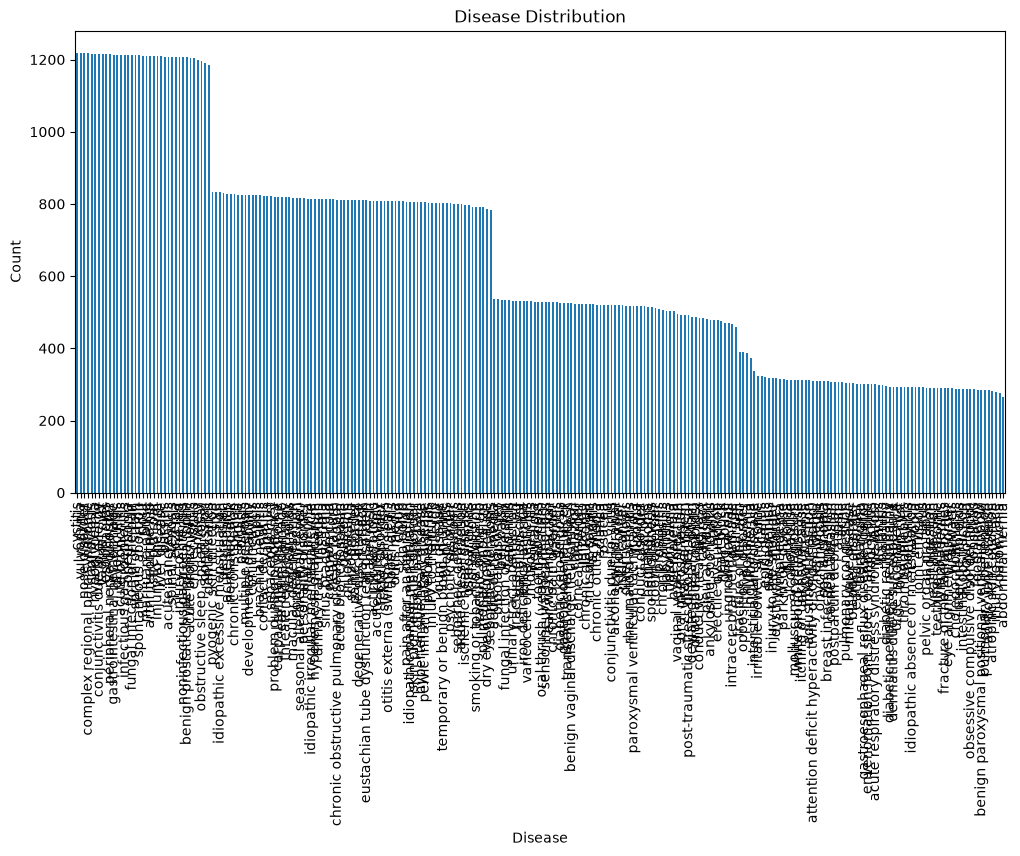

In [14]:
import matplotlib.pyplot as plt

df["diseases"].value_counts().plot(kind="bar", figsize=(12,6))

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

In [15]:
df["symptom_length"] = df["symptom_text"].apply(len)

df["symptom_length"].describe()

count    163727.000000
mean         91.030856
std          32.858123
min           5.000000
25%          68.000000
50%          88.000000
75%         112.000000
max         272.000000
Name: symptom_length, dtype: float64

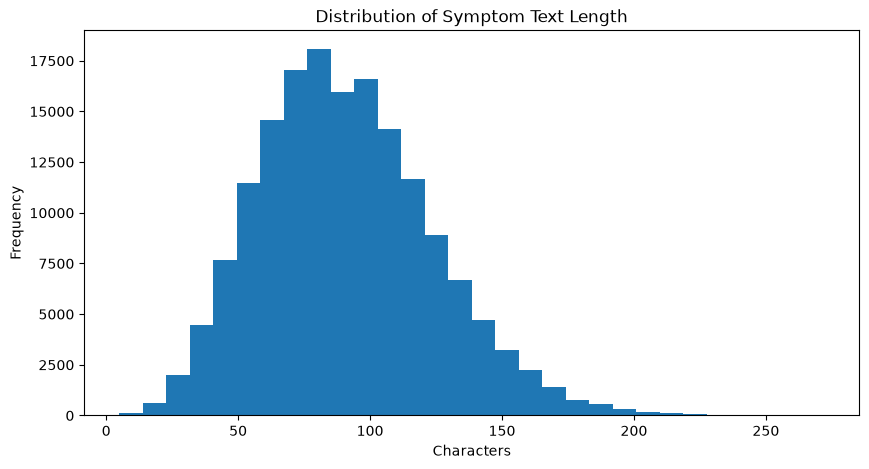

In [16]:
plt.figure(figsize=(10,5))

plt.hist(df["symptom_length"], bins=30)

plt.title("Distribution of Symptom Text Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [17]:
df.to_csv("../dataset/cleaned_dataset.csv", index=False)

In [18]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [19]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\raiva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [20]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [22]:
df["clean_text"] = df["symptom_text"].apply(clean_text)

In [23]:
df[["symptom_text", "clean_text"]].head(10)

,symptom_text,clean_text
0,"anxiety and nervousness, shortness of breath, ...",anxiety nervousness shortness breath depressiv...
1,"shortness of breath, depressive or psychotic s...",shortness breath depressive psychotic symptom ...
2,"anxiety and nervousness, depression, shortness...",anxiety nervousness depression shortness breat...
3,"anxiety and nervousness, depressive or psychot...",anxiety nervousness depressive psychotic sympt...
4,"anxiety and nervousness, depression, insomnia,...",anxiety nervousness depression insomnia abnorm...
5,"shortness of breath, depressive or psychotic s...",shortness breath depressive psychotic symptom ...
6,anxiety and nervousness,anxiety nervousness
7,"depressive or psychotic symptoms, insomnia, ab...",depressive psychotic symptom insomnia abnormal...
8,"anxiety and nervousness, depressive or psychot...",anxiety nervousness depressive psychotic sympt...
9,"anxiety and nervousness, depression, shortness...",anxiety nervousness depression shortness breat...


In [24]:
df.to_csv("../dataset/preprocessed_dataset.csv", index=False)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [26]:
X = df["clean_text"]

y = df["diseases"]

In [27]:
tfidf = TfidfVectorizer(max_features=5000)

In [28]:
X_tfidf = tfidf.fit_transform(X)

In [29]:
print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (163727, 285)


In [30]:
print(tfidf.get_feature_names_out()[:20])

['abdomen' 'abdominal' 'abnormal' 'abnormally' 'absence' 'abuse' 'abusing'
 'ache' 'acne' 'alcohol' 'allergic' 'anger' 'ankle' 'antisocial' 'anus'
 'anxiety' 'apnea' 'appearance' 'appearing' 'appetite']


In [32]:
import joblib

joblib.dump(tfidf, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']